In [23]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [24]:
import pbn_37k
from pbn_37k.ask import sigAssistant

import pandas as pd
from tqdm import tqdm
tqdm.pandas()

from dotenv import load_dotenv
load_dotenv()

brain = sigAssistant(pathCache=".cache/", llm_highend="gpt-4o",  llm_fast="gpt-4o-mini")

In [25]:
with open("data/cities/prompt/prompt.md", "r") as f:
    prompt_template = f.read()
with open("data/cities/activities.md", "r") as f:
    prompt_activity = f.read()
with open("data/cities/portfolio.md", "r") as f:
    prompt_portfolio = f.read()
with open("data/cities/prompt/cities.md", "r") as f:
    cities = [x.strip("*").strip() for x in f.read().split("\n") ]
cn = ["gotham", "baraddur", "kingslanding", "coruscant", "wakanda", "shire", "capitol"]

In [26]:
HEADER = """---
layout: default
title: TITLE
parent: PARENT
has_children: true
nav_order: NAVORDER
---\n\n"""

In [50]:
CITIES = {}
VISIONS = []
ACTIVITIES = []

for i in range(len(cities)):
    desc = cities[i]
    q = prompt_template.replace("$CITYNAME$", desc)
    urban_report = brain.ask(q)
    for k in range(3):
        urban_report = urban_report.replace("Page "+str(k+1)+": ", "").replace("---","")
    

    analysis = brain.analyseText( txt=urban_report,
            TypeOfItem = "Vision",
            Source="maptivity.online",
            Place=cn[i].title(),
            MIN=15,
            Reviewed=True,
            MODEL="gpt-4o-mini")
        

        
    CITIES[cn[i]] = {"report": urban_report}
    VISIONS.append(urban_report)

    
    report = HEADER.replace("TITLE", cn[i].title()).replace("NAVORDER", str(i+3)).replace("\nparent: PARENT","") + "![](places/"+cn[i]+".png)\n\n" + urban_report
    report = report.replace("## **Overview & Sustainability Profile**","## Overview & Sustainability Profile")
    SCORE = "\n\n### ISO37101 mapping for '"+analysis.Source_Title.unique()[0]+"'\n\n#### Scores\n\n" + analysis[["Score","Purpose","Issue","Justification"]].to_markdown(index=False)+"\n\n"
    report = report + SCORE


    
    with open(f"docs/{cn[i]}_report.md", "w") as f:
        f.write(report)

--- gpt-4o-mini:	 2025-10-23 11:48:36
Already done
--- gpt-4o-mini:	 2025-10-23 11:48:36
Already done
--- gpt-4o-mini:	 2025-10-23 11:48:36
Already done
--- gpt-4o-mini:	 2025-10-23 11:48:36
Already done
--- gpt-4o-mini:	 2025-10-23 11:48:36
Already done
--- gpt-4o-mini:	 2025-10-23 11:48:36
Already done
--- gpt-4o-mini:	 2025-10-23 11:48:36
Already done


In [ ]:
for i in range(len(cities)):
    desc = CITIES[cn[i]]["report"]
    q = prompt_portfolio.replace("DESCRIPTION", desc)
    urban_report = brain.ask(q)

    
    for k in range(3):
        urban_report = urban_report.replace("Page "+str(k+1)+": ", "").replace("---","")
    urban_report = "![](images/"+cn[i]+"_review.png)\n\n" + urban_report
    report = HEADER.replace("TITLE", cn[i].title()+"'s portfolio").replace("NAVORDER", "1").replace("PARENT",cn[i].title()) + urban_report
    CITIES[cn[i]]["portfolio"] = {"portfolio": report}
    with open(f"docs/{cn[i]}_portfolio.md", "w") as f:
        f.write(report)

    for k in range(7):
        q = prompt_activity.replace("$$DESC$$", desc).replace("$$ACT$$", urban_report)
        q = q.replace("$$NN$$ ", str(k+1))
        activity_report = brain.ask(q)
        ACTIVITIES.append(activity_report)
        CITIES[cn[i]]["portfolio"][f"activity_{k+1}"] = activity_report
        analysis = brain.analyseText( txt=activity_report,
                        TypeOfItem = "Activity",
                        Source="maptivity.online",
                        Place=cn[i].title(),
                        MIN=7,
                        Reviewed=False,
                        MODEL="gpt-4o-mini")

        reportB = activity_report


        SCORE = "\n\n### ISO37101 mapping for '"+analysis.Source_Title.unique()[0]+"'\n\n#### Scores\n\n" + analysis[["Score","Purpose","Issue","Justification"]].to_markdown(index=False)+"\n\n"

        reportB = reportB.replace("## **CONTEXTUAL FOUNDATION**",SCORE + "## **CONTEXTUAL FOUNDATION**")
        shorttitle = reportB.split("###")[1].split("\n")[1].replace("**","").split(":")[0].strip().replace('"','').replace("/","-")
        print(cn[i], k+1, shorttitle)
        reportB = HEADER.replace("TITLE", shorttitle).replace("NAVORDER", str(k+2)).replace("PARENT",cn[i].title()) + reportB
        reportB = reportB.replace("has_children: true _n","")


        with open(f"docs/{cn[i]}_activity_{k+1}.md", "w") as f:
            f.write(reportB)


    


--- gpt-4o-mini:	 2025-10-23 11:50:02
--- gpt-4o-mini:	 2025-10-23 11:50:02
Already done
gotham 1 Gotham Watch
--- gpt-4o-mini:	 2025-10-23 11:50:02
Old MIN: 7
New MIN: 7
--- Function call:	 2025-10-23 11:50:13
--- gpt-4o-mini:	 2025-10-23 11:50:14
--- gpt-4o-mini:	 2025-10-23 11:50:15
--- gpt-4o-mini:	 2025-10-23 11:50:16
--- gpt-4o-mini:	 2025-10-23 11:50:16
--- gpt-4o-mini:	 2025-10-23 11:50:17
--- gpt-4o-mini:	 2025-10-23 11:50:18
--- gpt-4o-mini:	 2025-10-23 11:50:18
--- gpt-4o-mini:	 2025-10-23 11:50:19
--- gpt-4o-mini:	 2025-10-23 11:50:21
--- gpt-4o-mini:	 2025-10-23 11:50:21
--- gpt-4o-mini:	 2025-10-23 11:50:22
--- gpt-4o-mini:	 2025-10-23 11:50:22
--- gpt-4o-mini:	 2025-10-23 11:50:22
--- gpt-4o-mini:	 2025-10-23 11:50:22
--- gpt-4o-mini:	 2025-10-23 11:50:22
--- gpt-4o-mini:	 2025-10-23 11:50:22
--- gpt-4o-mini:	 2025-10-23 11:50:22
--- gpt-4o-mini:	 2025-10-23 11:50:22
--- gpt-4o-mini:	 2025-10-23 11:50:22
--- gpt-4o-mini:	 2025-10-23 11:50:22
Good du premier coup, length 

# Reviews

In [ ]:
import pbn_37k.img as iImg
from pbn_37k.reportmgr import createExcel

df = brain.getMemory()
df = df[df.Source.isin(ACTIVITIES+VISIONS)]
print(len(df))
df.head(2)
df.Scale = df.Scale.str.strip().str.capitalize()
df.Scale = df.Scale.apply(lambda x: x.replace("Neighborhood","Neighbourhood").replace("City-wide","Neighbourhood"))
df.Scale = df.Scale.apply(lambda x: x.replace("District","Neighbourhood").replace("City","Neighbourhood"))
df.Scale = df.Scale.apply(lambda x: x.replace("Hyperlocal","Building"))
df.Scale.unique()

1169


array(['Neighbourhood', 'Building'], dtype=object)

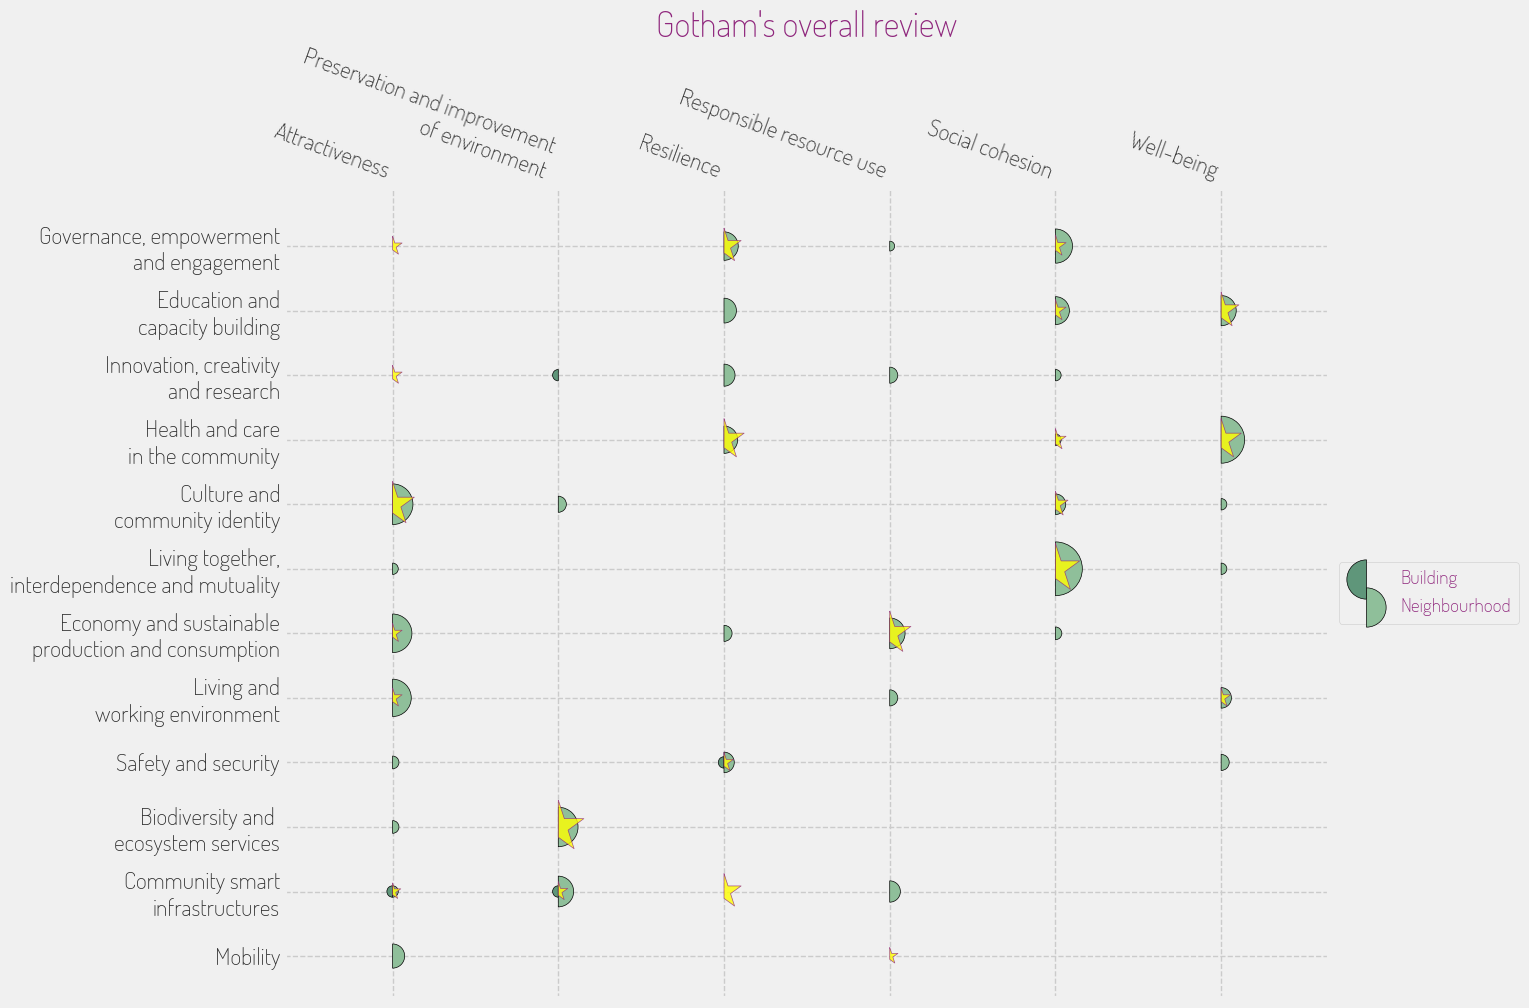

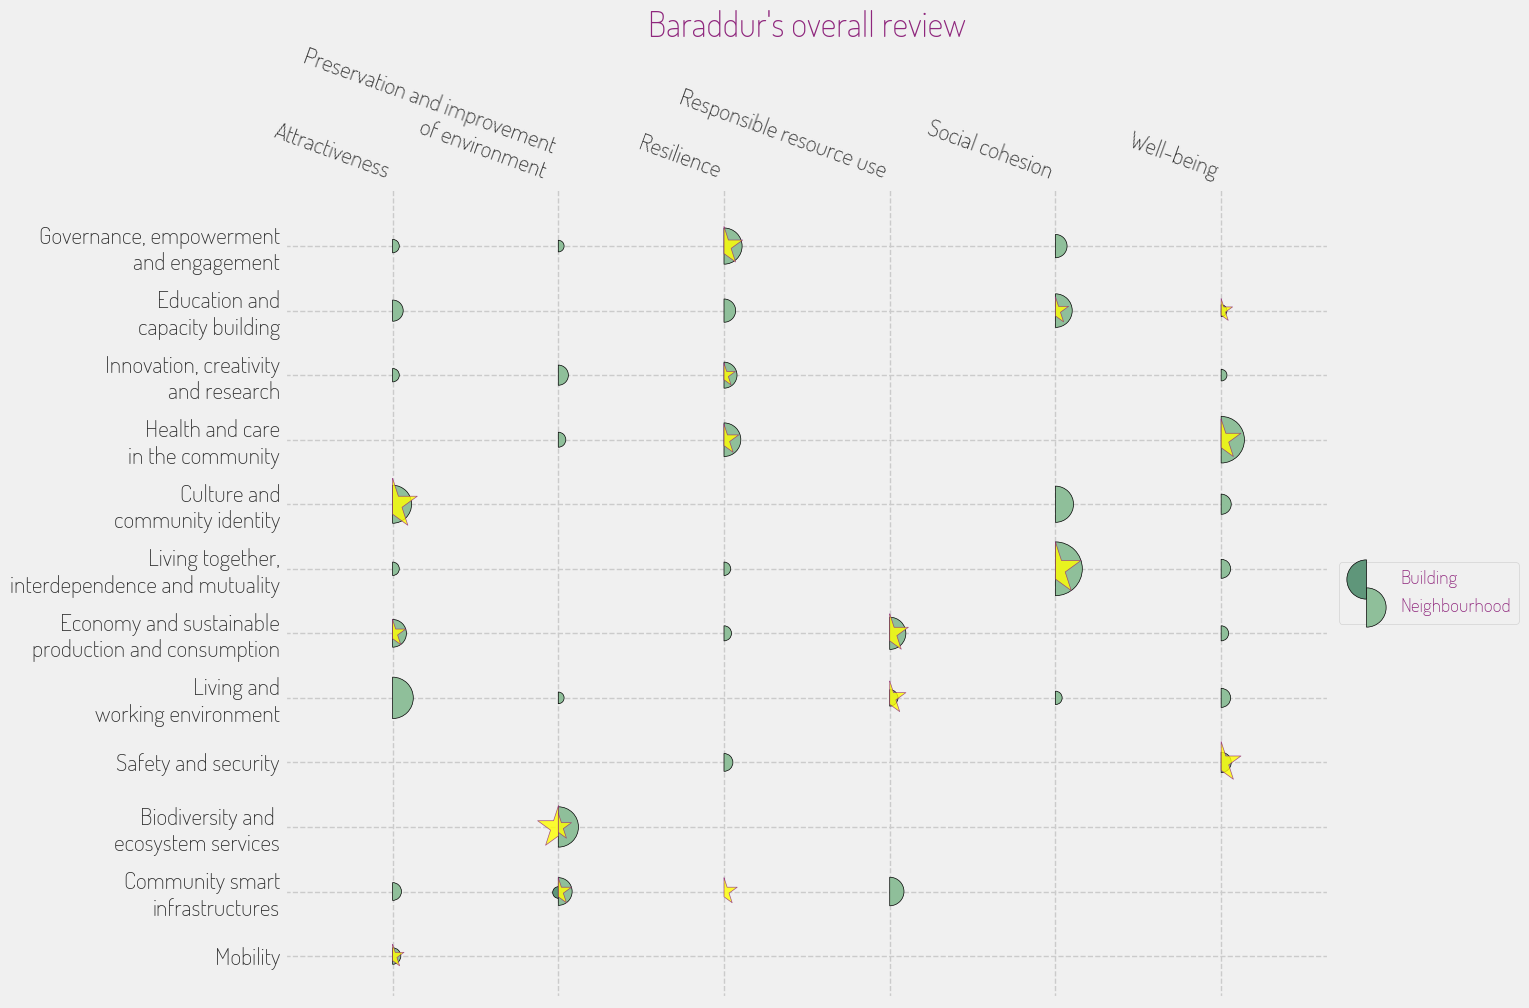

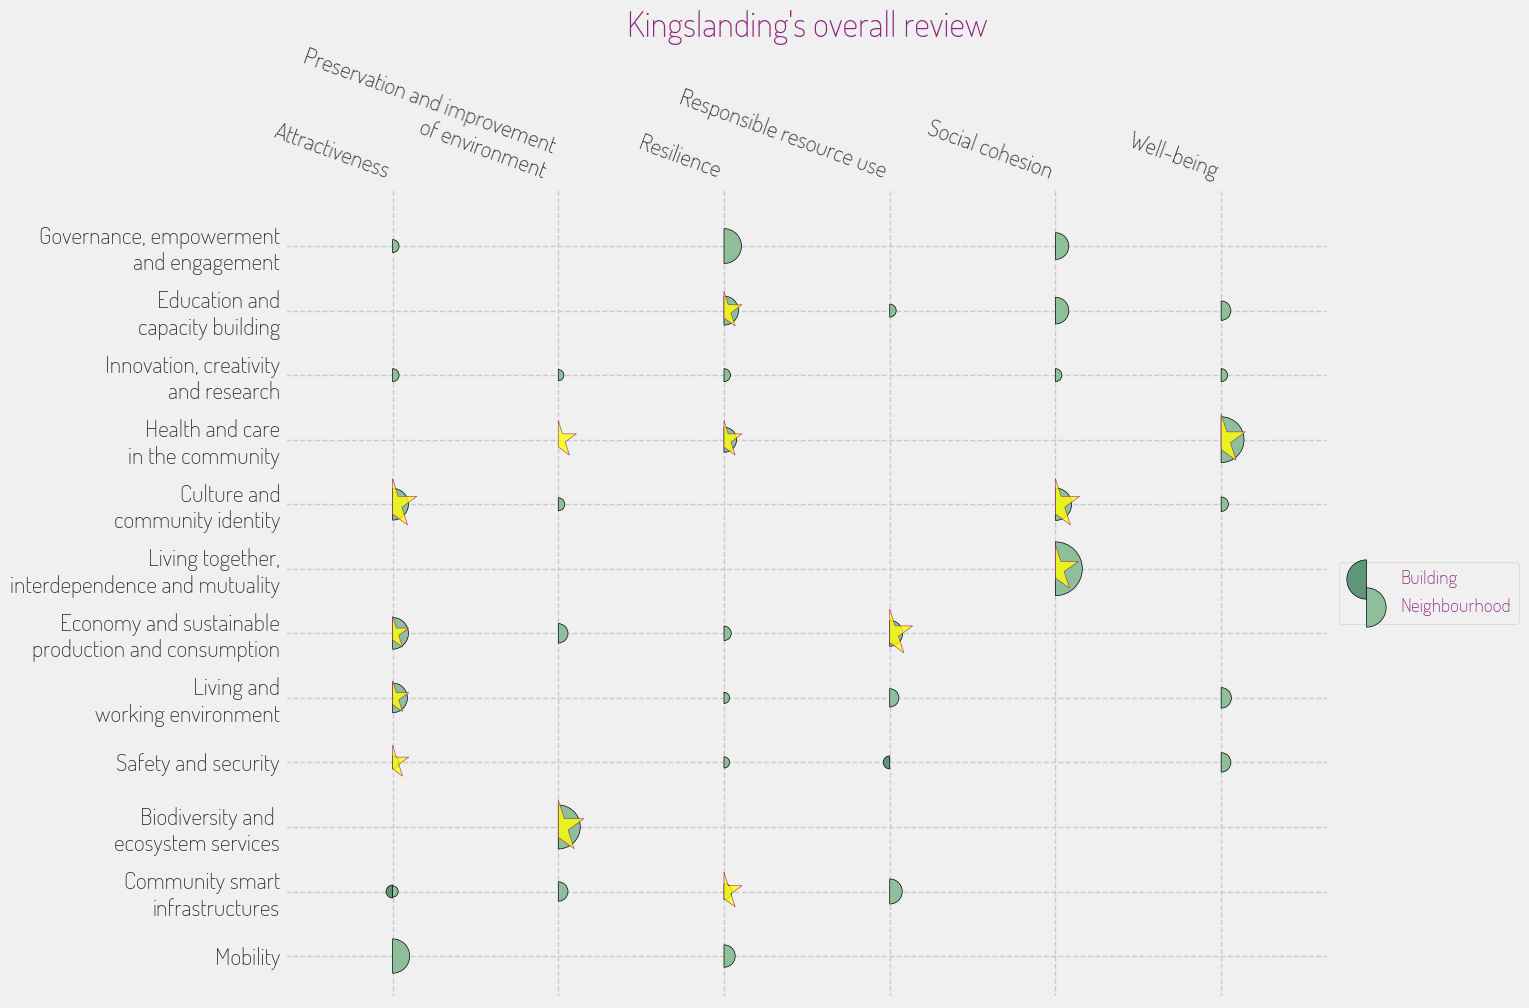

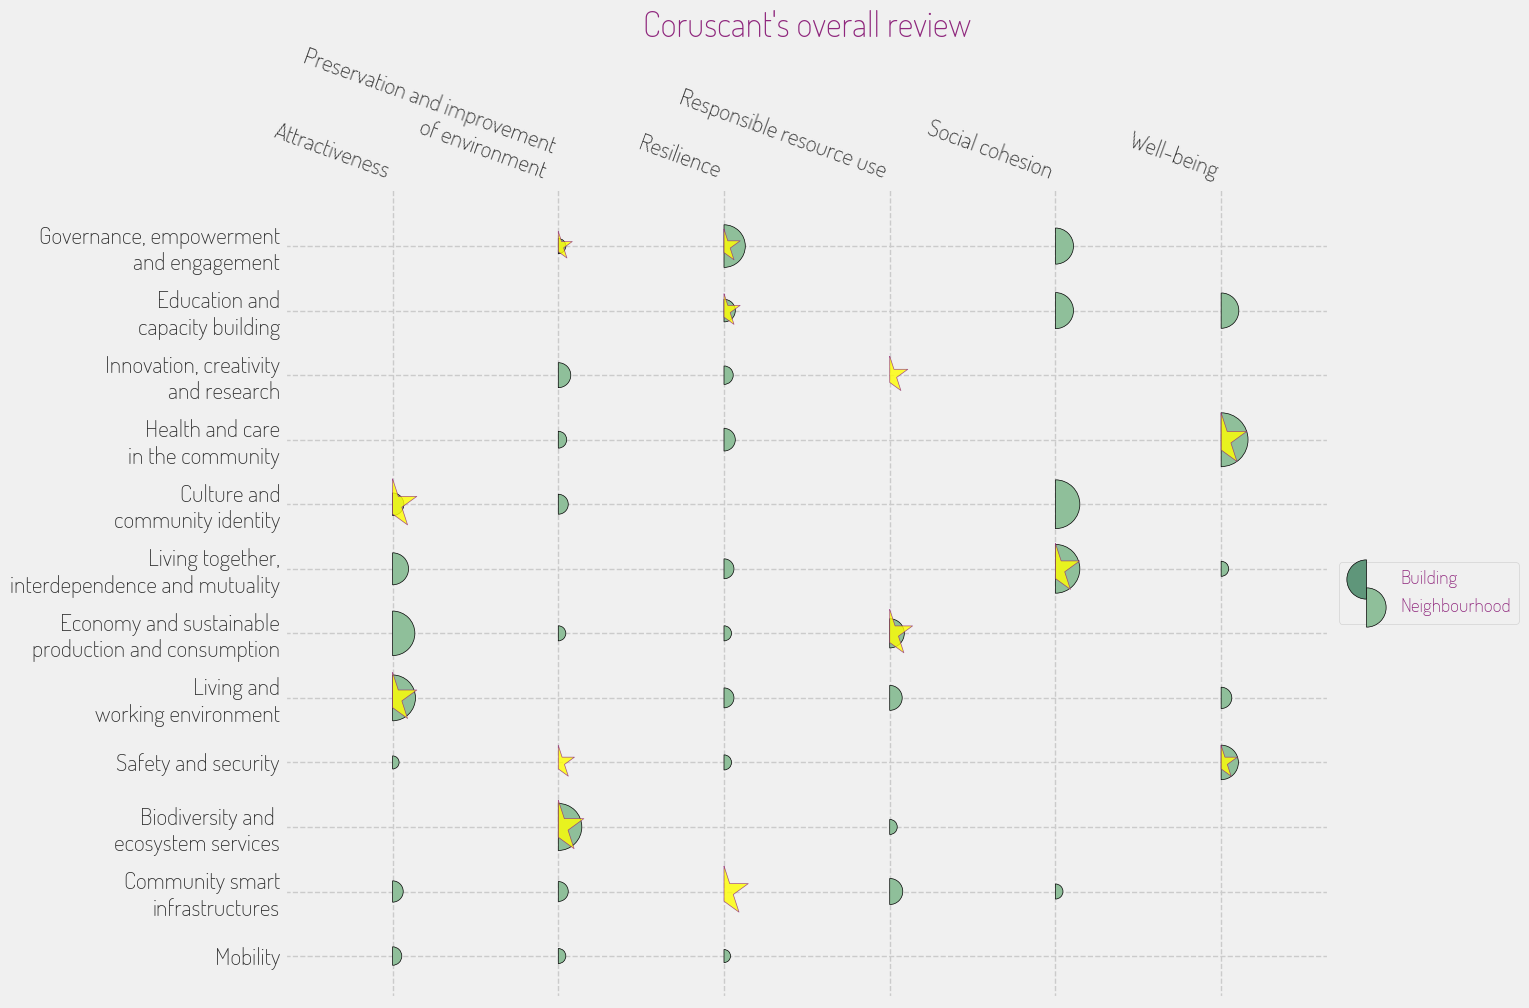

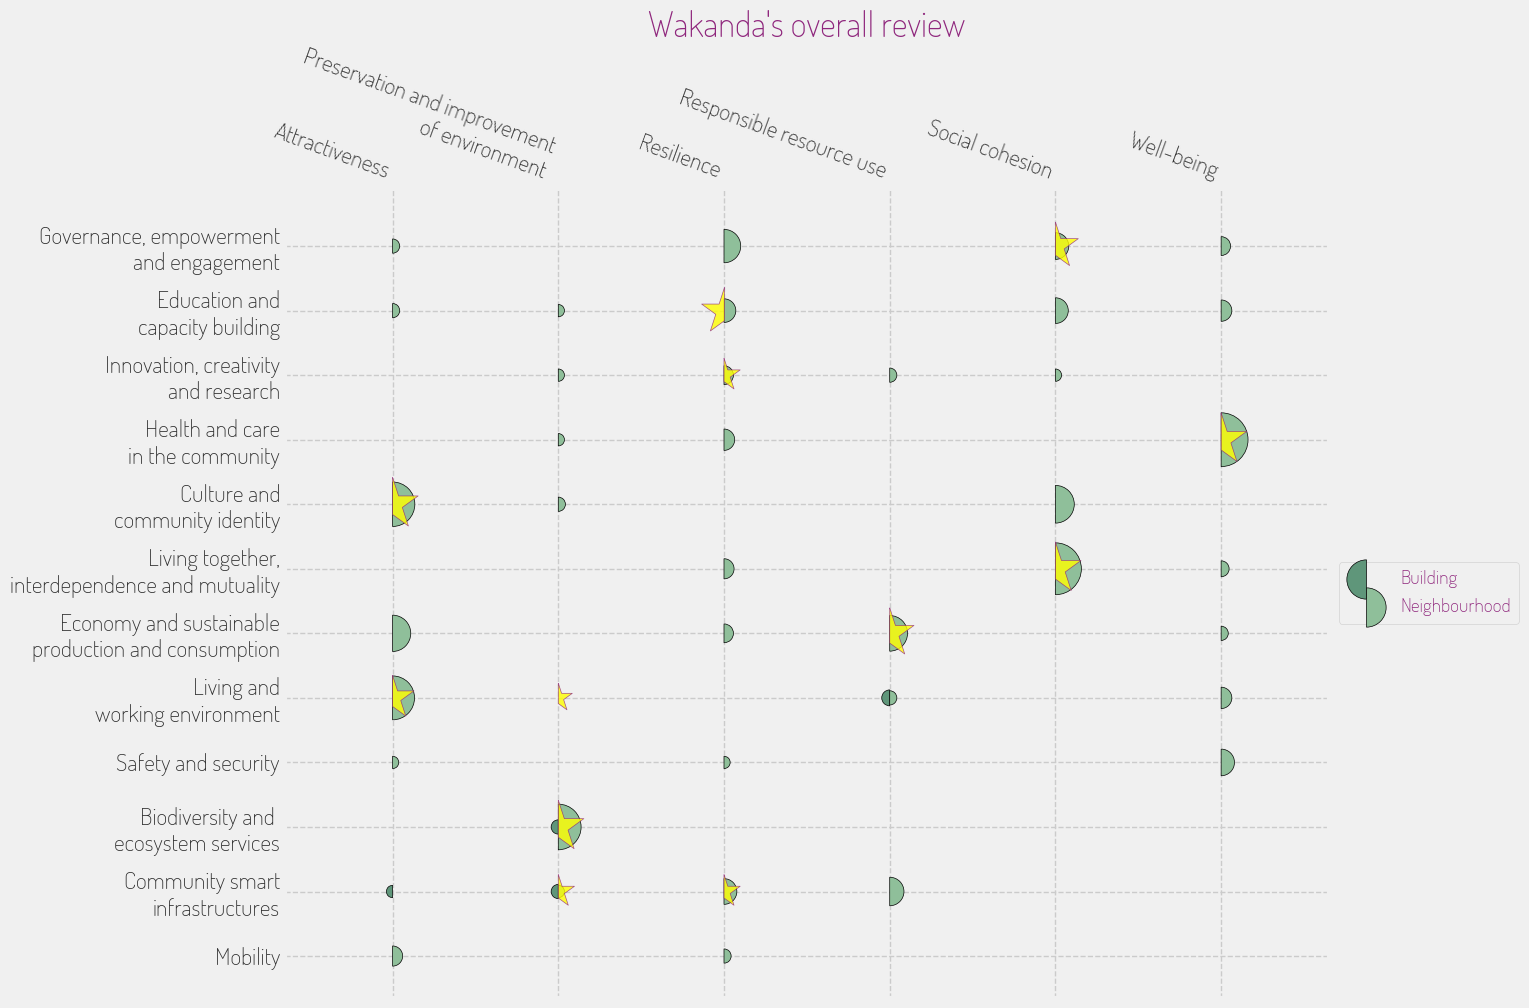

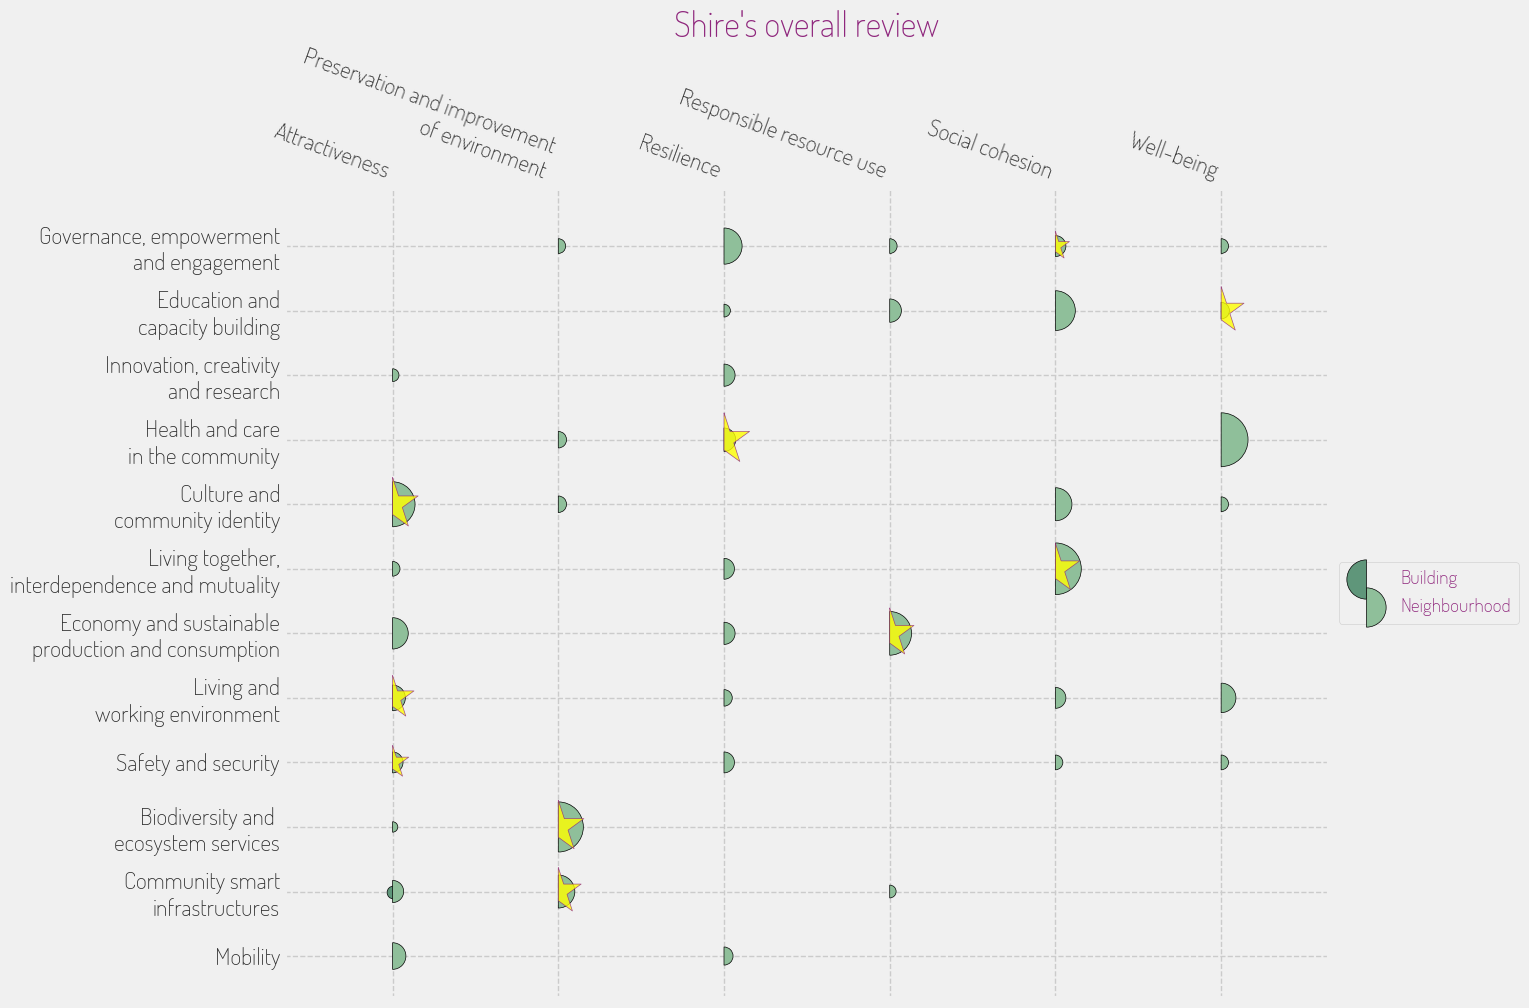

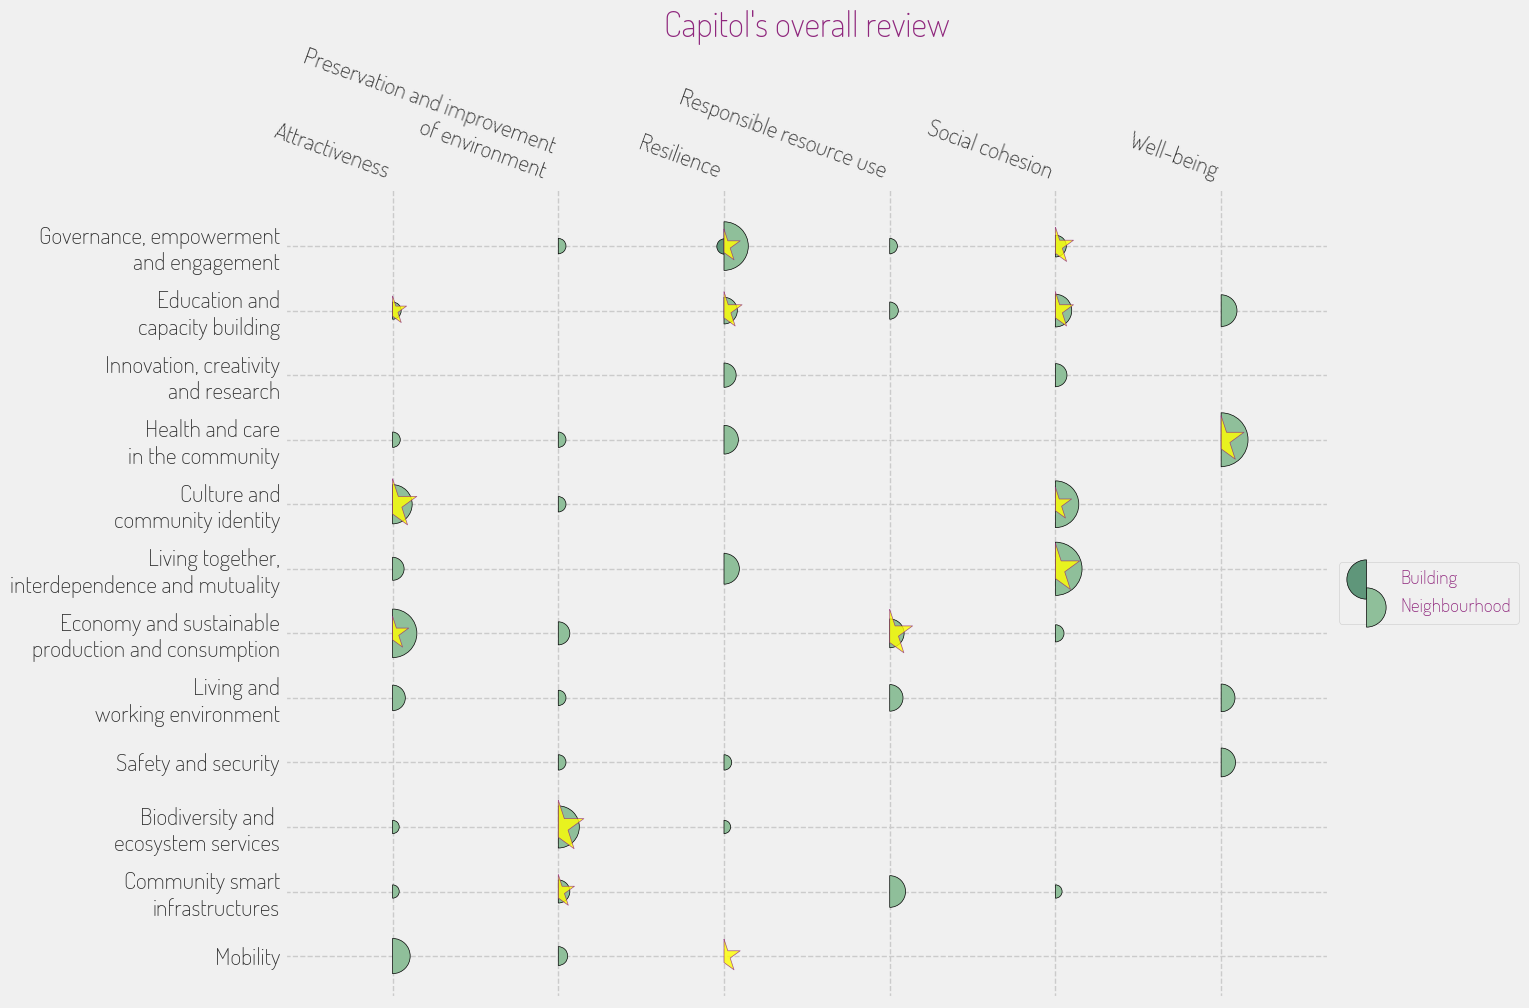

In [ ]:
for place in df.Place.unique():
    D = df[df.Place == place]
    dfRef = D[D.Type == "Vision"]
    dfRef = dfRef[dfRef. ]
    dfUC  = D[D.Type == "Activity"]
    plt, ax = iImg.createImg(dfUC, dfRef, title=place+"'s overall review")
    plt.savefig("docs/images/"+place.lower()+"_review.png",  bbox_inches="tight")

In [ ]:
%pip freeze > requirements.txt

Note: you may need to restart the kernel to use updated packages.
